# Logistic Regression SOPP

In [1]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [2]:
sopp_df = pd.read_csv("sopp_inflated.csv")

In [4]:
# Turn Year and Month into Categories
sopp_df['YEAR'] = sopp_df['YEAR'].astype('category')
sopp_df['MONTH_NAME'] = sopp_df['MONTH_NAME'].astype('category')

In [ ]:
sopp_df.head()

,date,time_segment,precinct,DAY_WEEK,STOP,MONTH,YEAR
0,2010-01-01,Late Night,CENTRAL,Friday,1,1,2010
1,2010-01-01,Late Night,EAST,Friday,1,1,2010
2,2010-01-01,Late Night,HERMITAGE,Friday,1,1,2010
3,2010-01-01,Late Night,MADISON,Friday,1,1,2010
4,2010-01-01,Late Night,MIDTOWN HILLS,Friday,1,1,2010


## Checking for Multicolinearity

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = pd.get_dummies(
    sopp_df[['precinct','time_segment','DAY_WEEK','YEAR','MONTH_NAME']],
    drop_first=True
)
X = X.astype(float)

import pandas as pd

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                      Variable       VIF
0                precinct_EAST  1.772894
1           precinct_HERMITAGE  1.772894
2             precinct_MADISON  1.772894
3       precinct_MIDTOWN HILLS  1.772894
4               precinct_NORTH  1.772894
5               precinct_SOUTH  1.772894
6           precinct_SOUTHEAST  1.772894
7                precinct_WEST  1.772894
8   time_segment_Early Morning  1.848596
9         time_segment_Evening  1.848596
10     time_segment_Late Night  1.848596
11        time_segment_Morning  1.848596
12          time_segment_Night  1.848596
13             DAY_WEEK_Monday  1.822842
14           DAY_WEEK_Saturday  1.824573
15             DAY_WEEK_Sunday  1.824605
16           DAY_WEEK_Thursday  1.823948
17            DAY_WEEK_Tuesday  1.823997
18          DAY_WEEK_Wednesday  1.823985
19                   YEAR_2011  1.767993
20                   YEAR_2012  1.770389
21                   YEAR_2013  1.767990
22                   YEAR_2014  1.767990
23              

# Fitting the Model

## Model with Temporal Only

In [8]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(sopp_df[['DAY_WEEK', 'time_segment', 'MONTH_NAME', "YEAR"]], drop_first=True)

# Target
y = sopp_df['STOP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Fitting the Model and Results

In [9]:
tem_model = LogisticRegression(max_iter=1000, class_weight = "balanced")
tem_model.fit(X_train, y_train)

y_prob = tem_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

### Classification Report

In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.23      0.69      0.34      3971
           1       0.95      0.71      0.82     32425

    accuracy                           0.71     36396
   macro avg       0.59      0.70      0.58     36396
weighted avg       0.87      0.71      0.76     36396



### ROC AUC

In [11]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.7763697990073369

### Confusion Matrix

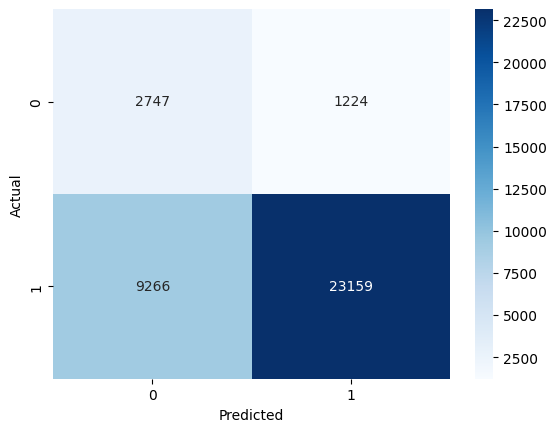

In [12]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance and Odds Ratio

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': tem_model.coef_[0],
    'Odds_Ratio': np.exp(tem_model.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
23                   YEAR_2012     0.921993    2.514296
24                   YEAR_2013     0.793330    2.210745
25                   YEAR_2014     0.510973    1.666912
10          time_segment_Night     0.461035    1.585714
22                   YEAR_2011     0.366956    1.443334
5           DAY_WEEK_Wednesday     0.364943    1.440432
7         time_segment_Evening     0.262117    1.299679
9         time_segment_Morning     0.147100    1.158470
4             DAY_WEEK_Tuesday     0.123114    1.131014
3            DAY_WEEK_Thursday     0.109161    1.115342
26                   YEAR_2015     0.005298    1.005312
17              MONTH_NAME_Mar    -0.033831    0.966735
16              MONTH_NAME_Jun    -0.084713    0.918776
14              MONTH_NAME_Jan    -0.097614    0.906999
27                   YEAR_2016    -0.132443    0.875953
11              MONTH_NAME_Aug    -0.165292    0.847646
15              MONTH_NAME_Jul    -0.191756    0

## Model with Precinct

In [15]:
# Sort by time
sopp_df = sopp_df.sort_values("date")

X = pd.get_dummies(sopp_df[['precinct', 'DAY_WEEK', 'time_segment', 'MONTH_NAME', 'YEAR']], drop_first=True)

# Target
y = sopp_df['STOP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
pre_model = LogisticRegression(max_iter=1000, class_weight = "balanced")
pre_model.fit(X_train, y_train)

y_prob = pre_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

### Classification Report

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.72      0.37      3971
           1       0.96      0.73      0.83     32425

    accuracy                           0.73     36396
   macro avg       0.60      0.72      0.60     36396
weighted avg       0.88      0.73      0.78     36396



### ROC AUC

In [18]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8027935687162925

### Confusion Matrix

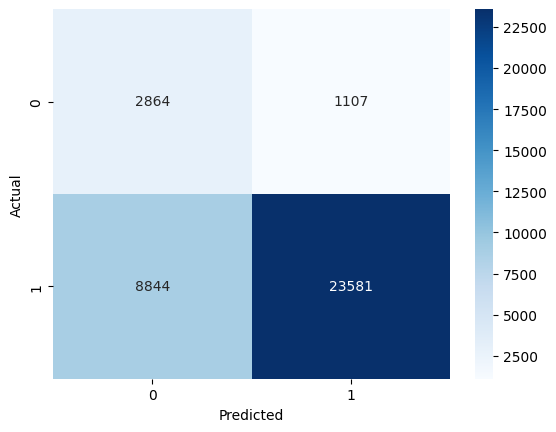

In [28]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../results/SOPP_confusion_matrix.png', bbox_inches='tight', facecolor='white')
plt.show()

### Feature Importance and Odds Ratios

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': pre_model.coef_[0],
    'Odds_Ratio': np.exp(pre_model.coef_[0]) 
}).sort_values(by='Coefficient', ascending=False)
feature_importance.to_csv('../results/SOPP_feature_importance.csv', index=False)
print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
5               precinct_SOUTH     1.068904    2.912185
3       precinct_MIDTOWN HILLS     0.981165    2.667562
31                   YEAR_2012     0.944773    2.572230
32                   YEAR_2013     0.856817    2.355651
0                precinct_EAST     0.814400    2.257820
1           precinct_HERMITAGE     0.581877    1.789393
33                   YEAR_2014     0.550407    1.733958
18          time_segment_Night     0.491130    1.634162
30                   YEAR_2011     0.396510    1.486627
13          DAY_WEEK_Wednesday     0.376974    1.457866
7                precinct_WEST     0.308272    1.361071
15        time_segment_Evening     0.274465    1.315827
17        time_segment_Morning     0.165900    1.180455
11           DAY_WEEK_Thursday     0.117072    1.124200
12            DAY_WEEK_Tuesday     0.116616    1.123688
4               precinct_NORTH     0.038373    1.039119
34                   YEAR_2015     0.021425    1